In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline
# for more beautiful plots
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [ ]:

bank_dataset = pd.read_csv("bank_test.csv")
bank_dataset.head()

,age,job,education,balance,loan,contact,subscribed
0,32.0,technician,tertiary,392,no,cellular,no
1,39.0,technician,secondary,688,yes,cellular,no
2,59.0,retired,secondary,1035,yes,cellular,no
3,47.0,blue-collar,secondary,398,yes,cellular,no
4,54.0,retired,secondary,1004,no,cellular,no


In [9]:
bank_dataset.describe()

,age,balance
count,995.000000,1000.00000
mean,42.059296,1437.51300
std,12.555130,2815.60663
min,19.000000,-980.00000
25%,33.000000,226.75000
50%,39.000000,562.00000
75%,50.000000,1724.00000
max,93.000000,31472.00000


Age has missing values. Balance has outliers

In [10]:
categorical_cols = [
    'job',
    'education',
    'loan',
    'contact',
    'subscribed'
]
for col in categorical_cols:
    print(f"total count: {bank_dataset[col].count()}, frequency table: {bank_dataset[col].value_counts()} \n")

total count: 996, frequency table: job
management       211
technician       166
blue-collar      147
admin.           136
retired           89
services          87
student           47
self-employed     39
unemployed        32
housemaid         23
entrepreneur      19
Name: count, dtype: int64 

total count: 950, frequency table: education
secondary    517
tertiary     323
primary      110
Name: count, dtype: int64 

total count: 1000, frequency table: loan
no     870
yes    130
Name: count, dtype: int64 

total count: 986, frequency table: contact
cellular     909
telephone     77
Name: count, dtype: int64 

total count: 1000, frequency table: subscribed
no     500
yes    500
Name: count, dtype: int64 



Job is missing 4 values. Education is missing 50. Loan is unbalanced. Contact is missing values.

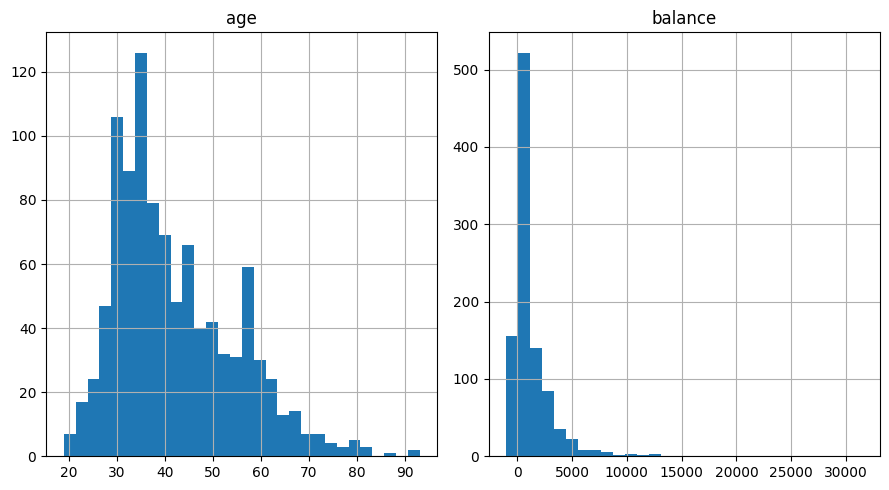

In [19]:
bank_dataset.hist(figsize=(9,5), bins=30)
plt.tight_layout()
plt.show()

(array([  4.,  13.,  16.,  15.,  47.,  61., 134.,  90., 115.,  91.,  64.,
         88.,  54.,  71.,  66.,  28.,  20.,   8.,   7.,   3.]),
 array([1.2787536 , 1.31324007, 1.34772654, 1.382213  , 1.41669947,
        1.45118594, 1.48567241, 1.52015887, 1.55464534, 1.58913181,
        1.62361827, 1.65810474, 1.69259121, 1.72707768, 1.76156414,
        1.79605061, 1.83053708, 1.86502355, 1.89951001, 1.93399648,
        1.96848295]),
 <BarContainer object of 20 artists>)

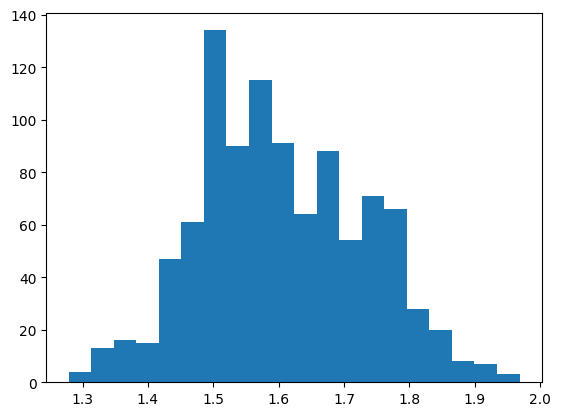

In [32]:
plt.hist(np.log10(bank_dataset['age']), bins=20)


In [33]:
bins = [0, 2000, 4000, 10000, 20000]
labels = ['0-2000', '2000-4000', '4000-10000', '10000-20000']

bank_dataset['balance_range'] = pd.cut(bank_dataset['balance'], bins=bins, labels=labels)

bank_dataset['balance_range'].value_counts(normalize=True) * 100

balance_range
0-2000         78.046103
2000-4000      14.270033
4000-10000      6.476400
10000-20000     1.207464
Name: proportion, dtype: float64

In [35]:
bank_dataset['balance'].median()

np.float64(562.0)

In [37]:
df_secondary = bank_dataset[bank_dataset['education'] == 'secondary']
df_secondary['age'].median()

np.float64(39.0)

In [27]:
bank_dataset['education'].value_counts(normalize=True) * 100

education
secondary    54.421053
tertiary     34.000000
primary      11.578947
Name: proportion, dtype: float64

In [39]:
bank_dataset[
    (bank_dataset['loan'] == 'yes') & (bank_dataset['balance'] > 20000)
] 

,age,job,education,balance,loan,contact,subscribed,balance_range


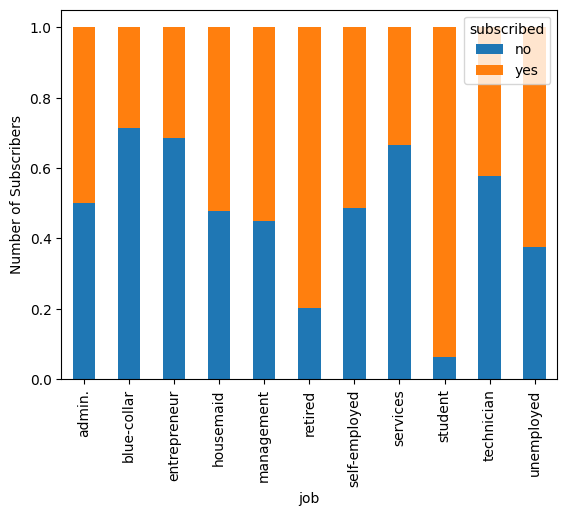

job
management       211
technician       166
blue-collar      147
admin.           136
retired           89
services          87
student           47
self-employed     39
unemployed        32
housemaid         23
entrepreneur      19
Name: count, dtype: int64

In [34]:
# Stacked bar chart of the number of subscribers by education level
crosstab_ES = pd.crosstab(bank_dataset['job'], bank_dataset['subscribed'], normalize='index')
crosstab_ES.plot(kind='bar', stacked=True)
plt.ylabel('Number of Subscribers')
plt.show()
bank_dataset['job'].value_counts()

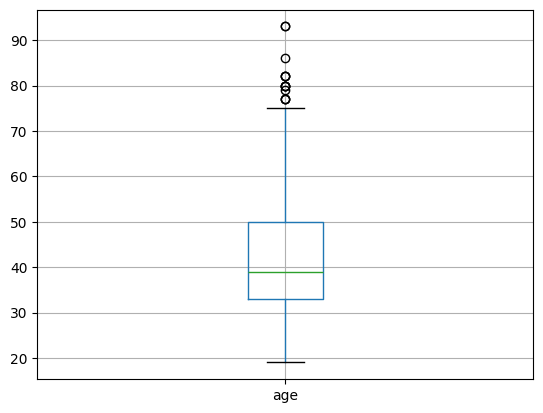

<Axes: >

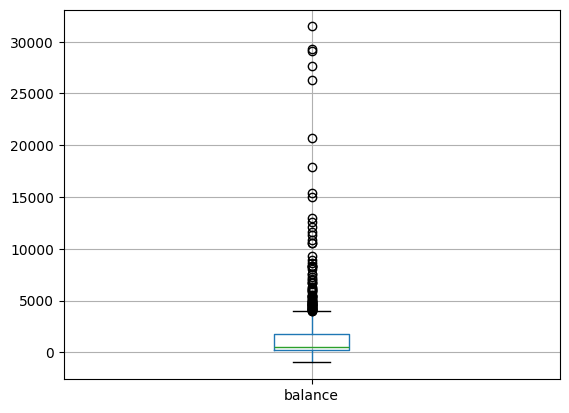

In [20]:
bank_dataset.boxplot(column='age')
plt.show()
bank_dataset.boxplot(column='balance')
